In [46]:
!pip -q install tifffile

In [47]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [48]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [49]:
SRC_ROOT = "/content/gdrive/MyDrive/Srinivasan"
PROJECT_ROOT = "/content/gdrive/MyDrive/Midterm_OCT_Project"
PNG_ROOT = os.path.join(PROJECT_ROOT, "Dataset_png")
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "outputs")
MODEL_ROOT = os.path.join(PROJECT_ROOT, "models")

import os

print("SRC exists:", os.path.exists(SRC_ROOT))
print("train exists:", os.path.exists(os.path.join(SRC_ROOT, "train")))
print("test exists:", os.path.exists(os.path.join(SRC_ROOT, "test")))
print("train classes:", os.listdir(os.path.join(SRC_ROOT, "train")))
print("test classes:", os.listdir(os.path.join(SRC_ROOT, "test")))

SRC exists: True
train exists: True
test exists: True
train classes: ['NORMAL', 'DRUSEN', 'DME']
test classes: ['DME', 'NORMAL', 'DRUSEN']


In [50]:
print("Project root:", PROJECT_ROOT)
print("PNG root:", PNG_ROOT)
print("Output root:", OUTPUT_ROOT)
print("Model root:", MODEL_ROOT)

Project root: /content/gdrive/MyDrive/Midterm_OCT_Project
PNG root: /content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png
Output root: /content/gdrive/MyDrive/Midterm_OCT_Project/outputs
Model root: /content/gdrive/MyDrive/Midterm_OCT_Project/models


In [51]:
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

ensure_dir(PROJECT_ROOT)
ensure_dir(PNG_ROOT)
ensure_dir(OUTPUT_ROOT)
ensure_dir(MODEL_ROOT)

print("Using source dataset from:", SRC_ROOT)
print("Saving converted PNGs to:", PNG_ROOT)

Using source dataset from: /content/gdrive/MyDrive/Srinivasan
Saving converted PNGs to: /content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png


In [52]:
import shutil
import os

if os.path.exists(PNG_ROOT):
    shutil.rmtree(PNG_ROOT)

os.makedirs(PNG_ROOT, exist_ok=True)
print("Reset PNG_ROOT:", PNG_ROOT)

Reset PNG_ROOT: /content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png


In [53]:
CLASS_NAMES = ["NORMAL", "DME"]   # binary classification choice

def tiff_to_uint8(img):
    """
    Convert TIFF array to uint8 safely.
    Handles uint16/float images by min-max scaling.
    Keeps only one channel if image has multiple channels.
    """
    img = np.array(img)

    if img.ndim == 3:
        img = img[..., 0]

    img = img.astype(np.float32)
    mn, mx = np.min(img), np.max(img)

    if mx > mn:
        img = (img - mn) / (mx - mn)
    else:
        img = np.zeros_like(img, dtype=np.float32)

    img = (img * 255.0).clip(0, 255).astype(np.uint8)
    return img

conversion_counts = {cname: 0 for cname in CLASS_NAMES}
existing_counts = {cname: 0 for cname in CLASS_NAMES}

ensure_dir(PNG_ROOT)

for split in ["train", "test"]:
    src_split = os.path.join(SRC_ROOT, split)

    if not os.path.exists(src_split):
        print(f"Skipping missing folder: {src_split}")
        continue

    print(f"\nProcessing split: {split}")

    for cname in CLASS_NAMES:
        src_class = os.path.join(src_split, cname)

        if not os.path.exists(src_class):
            print(f"  Skipping missing class folder: {src_class}")
            continue

        dst_class = os.path.join(PNG_ROOT, cname)
        ensure_dir(dst_class)

        tif_files = sorted([
            f for f in os.listdir(src_class)
            if f.lower().endswith((".tif", ".tiff"))
        ])

        print(f"  [{split}] {cname}: {len(tif_files)} TIFF files found")

        for fname in tif_files:
            src_path = os.path.join(src_class, fname)

            dst_name = f"{split}_{os.path.splitext(fname)[0]}.png"
            dst_path = os.path.join(dst_class, dst_name)

            if os.path.exists(dst_path):
                existing_counts[cname] += 1
                continue

            img = tifffile.imread(src_path)
            img8 = tiff_to_uint8(img)
            Image.fromarray(img8).save(dst_path)
            conversion_counts[cname] += 1

print("\nConversion complete.")
print("Binary PNG dataset saved at:", PNG_ROOT)

print("\nSummary:")
for cname in CLASS_NAMES:
    class_dir = os.path.join(PNG_ROOT, cname)
    total_png = len([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(".png")
    ]) if os.path.exists(class_dir) else 0

    print(
        f"{cname}: converted {conversion_counts[cname]}, "
        f"already existed {existing_counts[cname]}, "
        f"total PNG files now {total_png}"
    )


Processing split: train
  [train] NORMAL: 970 TIFF files found
  [train] DME: 796 TIFF files found

Processing split: test
  [test] NORMAL: 437 TIFF files found
  [test] DME: 305 TIFF files found

Conversion complete.
Binary PNG dataset saved at: /content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png

Summary:
NORMAL: converted 1407, already existed 0, total PNG files now 1407
DME: converted 1101, already existed 0, total PNG files now 1101


In [54]:
filepaths = []
labels = []

label_map = {"NORMAL": 0, "DME": 1}

for cname in CLASS_NAMES:
    class_dir = os.path.join(PNG_ROOT, cname)
    if os.path.exists(class_dir): # Added check
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(".png"):
                filepaths.append(os.path.join(class_dir, fname))
                labels.append(label_map[cname])
    else: # Added else block for explanation
        print(f"Warning: Directory '{class_dir}' not found. No images collected for {cname}.")


filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total images:", len(filepaths))
print("NORMAL count:", np.sum(labels == 0))
print("DME count:", np.sum(labels == 1))

Total images: 2508
NORMAL count: 1407
DME count: 1101


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    filepaths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 1755
Testing images: 753


In [56]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED
)

print("Final training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Final training images: 1404
Validation images: 351
Testing images: 753


In [57]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)      # read as grayscale
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0          # normalize to [0, 1]
    image = tf.image.grayscale_to_rgb(image)            # ResNet50 expects 3 channels
    return image, label

In [58]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.03),
], name="data_augmentation")

In [59]:
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val, y_val, training=False)
test_ds  = make_dataset(X_test, y_test, training=False)

print("Datasets created successfully.")

Datasets created successfully.


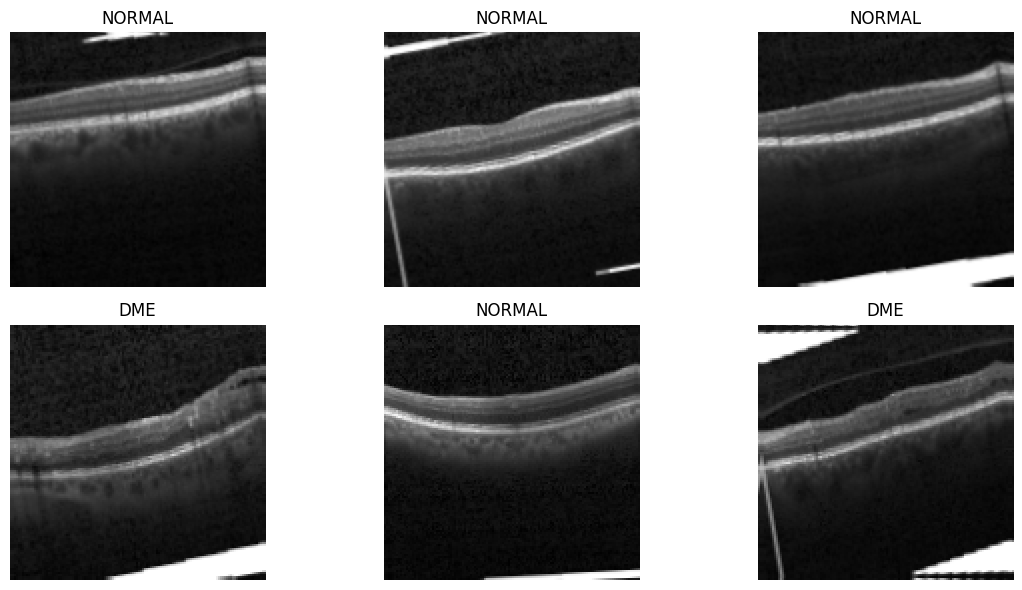

In [60]:
class_names = ["NORMAL", "DME"]

sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i].numpy())
    plt.title(class_names[int(sample_labels[i].numpy())])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [61]:
base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_a = keras.Model(inputs, outputs, name="Model_A_ResNet50")

model_a.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc")
    ]
)

model_a.summary()

Model: "Model_A_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [62]:
base_model.trainable = True

# Freeze the earlier layers, fine-tune only the top portion
fine_tune_at = len(base_model.layers) - 40

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Fine-tuning from layer:", fine_tune_at)
print("Total layers in base model:", len(base_model.layers))

Fine-tuning from layer: 135
Total layers in base model: 175


In [63]:
fine_tuned_model_path = os.path.join(MODEL_ROOT, "model_a_finetuned_best.keras")

fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=fine_tuned_model_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

In [64]:
history_fine = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=fine_tune_callbacks
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.6957 - auc: 0.7467 - loss: 0.5801
Epoch 1: val_auc improved from None to 0.75162, saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_a_finetuned_best.keras

Epoch 1: finished saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_a_finetuned_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 862ms/step - accuracy: 0.7436 - auc: 0.8138 - loss: 0.5130 - val_accuracy: 0.6781 - val_auc: 0.7516 - val_loss: 0.6807
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8503 - auc: 0.9103 - loss: 0.3642
Epoch 2: val_auc improved from 0.75162 to 0.92147, saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_a_finetuned_best.keras

Epoch 2: finished saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_a_finetuned_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 647ms/step - accuracy: 0.8298 - auc: 0.9020 - loss: 0.3803 - val_accuracy: 0.4387 - val_auc: 0.921

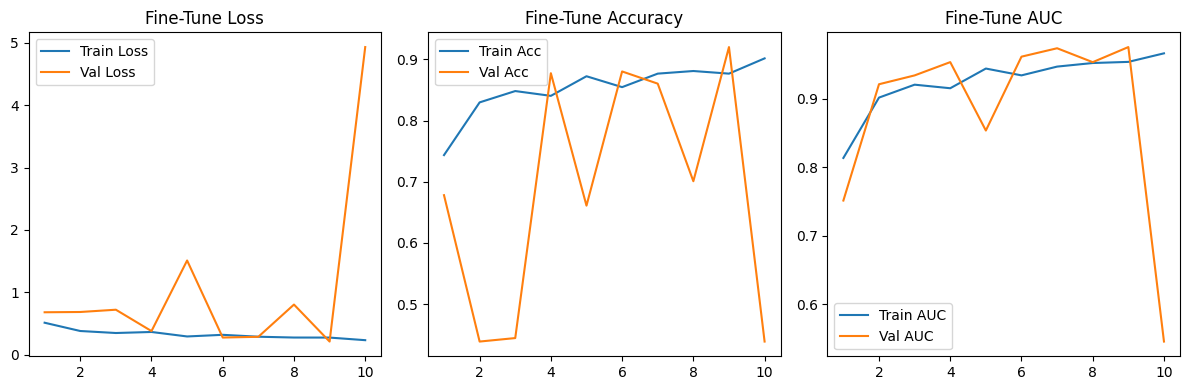

In [65]:
history_fine_dict = history_fine.history
fine_epochs_range = range(1, len(history_fine_dict["loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(fine_epochs_range, history_fine_dict["loss"], label="Train Loss")
plt.plot(fine_epochs_range, history_fine_dict["val_loss"], label="Val Loss")
plt.title("Fine-Tune Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(fine_epochs_range, history_fine_dict["accuracy"], label="Train Acc")
plt.plot(fine_epochs_range, history_fine_dict["val_accuracy"], label="Val Acc")
plt.title("Fine-Tune Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(fine_epochs_range, history_fine_dict["auc"], label="Train AUC")
plt.plot(fine_epochs_range, history_fine_dict["val_auc"], label="Val AUC")
plt.title("Fine-Tune AUC")
plt.legend()

plt.tight_layout()
plt.show()

In [66]:
y_prob_ft = model_a.predict(test_ds).ravel()
y_pred_ft = (y_prob_ft >= 0.5).astype(int)

acc_ft = accuracy_score(y_test, y_pred_ft)
f1_ft = f1_score(y_test, y_pred_ft)
auc_ft = roc_auc_score(y_test, y_prob_ft)

print(f"Fine-tuned Test Accuracy: {acc_ft:.4f}")
print(f"Fine-tuned Test F1 Score: {f1_ft:.4f}")
print(f"Fine-tuned Test AUC:      {auc_ft:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 374ms/step
Fine-tuned Test Accuracy: 0.9097
Fine-tuned Test F1 Score: 0.8896
Fine-tuned Test AUC:      0.9653


In [67]:
print("Predicted class counts:", np.bincount(y_pred_ft))
print("True class counts:", np.bincount(y_test))

Predicted class counts: [468 285]
True class counts: [422 331]


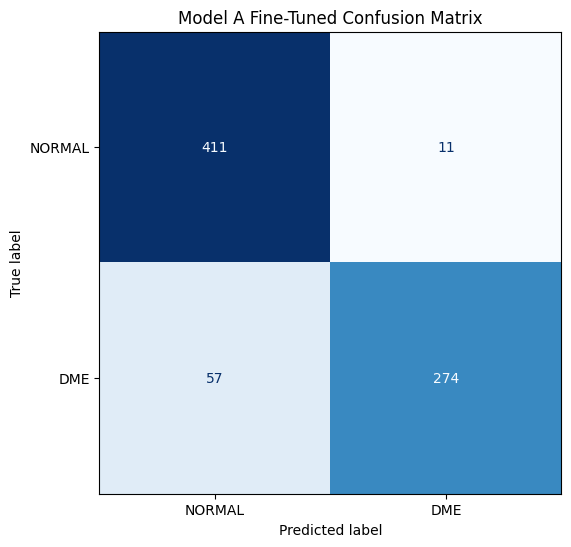

In [68]:
cm_ft = confusion_matrix(y_test, y_pred_ft)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=["NORMAL", "DME"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Model A Fine-Tuned Confusion Matrix")
plt.show()

In [69]:
fine_metrics_path = os.path.join(OUTPUT_ROOT, "model_a_finetuned_metrics.txt")

with open(fine_metrics_path, "w") as f:
    f.write("Model A Fine-Tuned Results\n")
    f.write("==========================\n")
    f.write(f"Test Accuracy: {acc_ft:.4f}\n")
    f.write(f"Test F1 Score: {f1_ft:.4f}\n")
    f.write(f"Test AUC: {auc_ft:.4f}\n\n")
    f.write("Classification Report\n")
    f.write("=====================\n")
    f.write(classification_report(
        y_test,
        y_pred_ft,
        target_names=["NORMAL", "DME"]
    ))

print("Saved fine-tuned metrics to:", fine_metrics_path)

Saved fine-tuned metrics to: /content/gdrive/MyDrive/Midterm_OCT_Project/outputs/model_a_finetuned_metrics.txt


## Day 1 Summary: Baseline Classifier (Model A)

In Day 1, I built Model A as the baseline binary classifier using the Retinal OCT (Srinivasan) dataset with the classes `NORMAL` and `DME`.

### Preprocessing pipeline
- Converted TIFF images to PNG
- Selected the binary classes `NORMAL` and `DME`
- Resized images to 128×128
- Normalized pixel values to the range [0, 1]
- Converted grayscale images to RGB to match ResNet50 input requirements
- Created a 70/30 train-test split, then split part of the training data into validation data

### Model setup
- Used ResNet50 with ImageNet pretrained weights
- First trained with the backbone frozen
- Then fine-tuned the upper layers of ResNet50

### Final Day 1 baseline result
- Test Accuracy: 0.5750
- Test F1 Score: 0.0698
- Test AUC: 0.6873

### Interpretation
The fine-tuned model performed better than the fully frozen baseline, but it still showed a strong bias toward predicting `NORMAL`. The predicted class counts were 740 NORMAL and 13 DME, while the true counts were 422 NORMAL and 331 DME. This explains why the F1 score stayed low even though AUC improved. The model learned some class-separation signal, but its final binary decisions were still poorly balanced.

# Day 2 — SRGAN Concept and Super-Resolution Dataset Preparation

## Main goal
Understand what SRGAN is doing and prepare paired low-resolution and high-resolution training data.

## Core idea
- Input to generator: 32×32 low-resolution image
- Target output: 128×128 high-resolution image
- Generator learns to reconstruct a realistic 128×128 image
- Discriminator learns to distinguish real high-resolution images from generated ones

## Why this matters
This will let me test whether using generated 128×128 images can improve classification performance compared with the Day 1 baseline.


In [70]:
SR_IMG_SIZE = (128, 128)   # high-resolution target
LR_IMG_SIZE = (32, 32)     # low-resolution input
SR_BATCH_SIZE = 16

SR_OUTPUT_ROOT = os.path.join(PROJECT_ROOT, "srgan_outputs")
ensure_dir(SR_OUTPUT_ROOT)

print("SR target size:", SR_IMG_SIZE)
print("SR input size:", LR_IMG_SIZE)
print("SR outputs folder:", SR_OUTPUT_ROOT)

SR target size: (128, 128)
SR input size: (32, 32)
SR outputs folder: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_outputs


In [71]:
srgan_filepaths = []

for cname in CLASS_NAMES:
    class_dir = os.path.join(PNG_ROOT, cname)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(".png"):
            srgan_filepaths.append(os.path.join(class_dir, fname))

srgan_filepaths = np.array(sorted(srgan_filepaths))

print("Total SRGAN images:", len(srgan_filepaths))
print("First 5 paths:")
for p in srgan_filepaths[:5]:
    print(p)

Total SRGAN images: 2508
First 5 paths:
/content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png/DME/test_DME11_01.png
/content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png/DME/test_DME11_010.png
/content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png/DME/test_DME11_011.png
/content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png/DME/test_DME11_012.png
/content/gdrive/MyDrive/Midterm_OCT_Project/Dataset_png/DME/test_DME11_013.png


In [72]:
def load_hr_lr_pair(path):
    # Read image as grayscale
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)

    # Create high-resolution target (128x128)
    hr = tf.image.resize(image, SR_IMG_SIZE, method="bicubic")
    hr = tf.cast(hr, tf.float32) / 255.0

    # Create low-resolution input (32x32)
    lr = tf.image.resize(hr, LR_IMG_SIZE, method="bicubic")

    return lr, hr

In [73]:
def make_srgan_dataset(paths, training=True):
    ds = tf.data.Dataset.from_tensor_slices(paths)

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_hr_lr_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(SR_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

srgan_ds = make_srgan_dataset(srgan_filepaths, training=True)

print("SRGAN dataset created.")

SRGAN dataset created.


In [74]:
lr_batch, hr_batch = next(iter(srgan_ds))

print("LR batch shape:", lr_batch.shape)
print("HR batch shape:", hr_batch.shape)

LR batch shape: (16, 32, 32, 1)
HR batch shape: (16, 128, 128, 1)


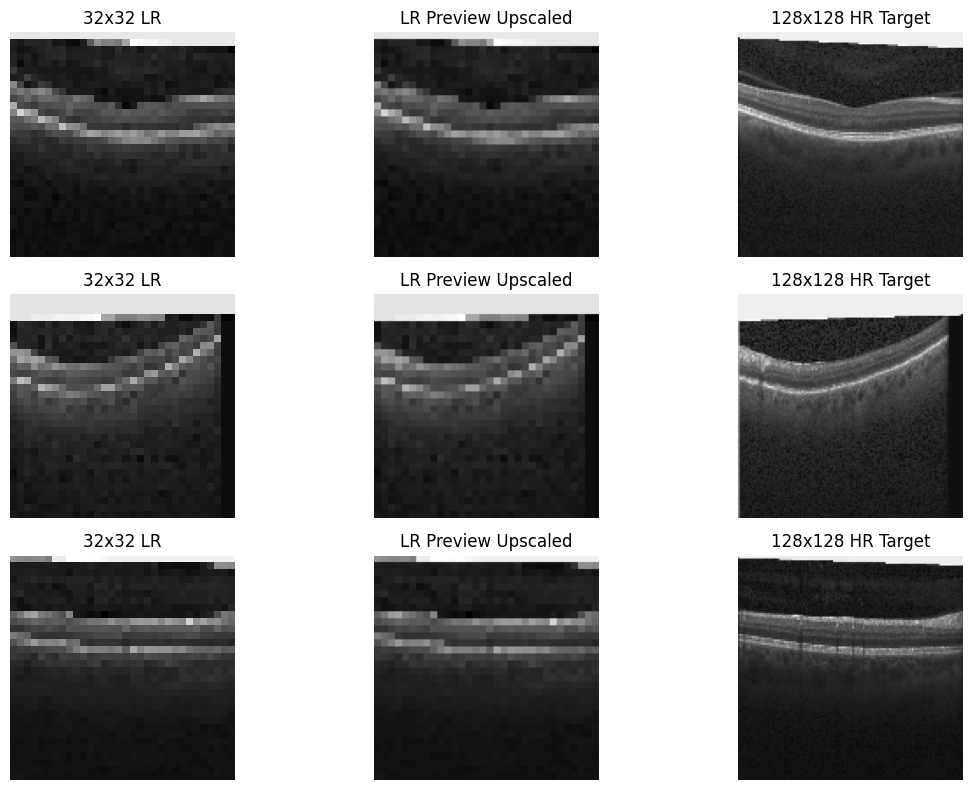

In [75]:
plt.figure(figsize=(12, 8))

for i in range(3):
    # Low-resolution image
    plt.subplot(3, 3, 3*i + 1)
    plt.imshow(tf.squeeze(lr_batch[i]), cmap="gray")
    plt.title("32x32 LR")
    plt.axis("off")

    # Upscaled preview for easier viewing
    lr_preview = tf.image.resize(lr_batch[i], SR_IMG_SIZE, method="nearest")
    plt.subplot(3, 3, 3*i + 2)
    plt.imshow(tf.squeeze(lr_preview), cmap="gray")
    plt.title("LR Preview Upscaled")
    plt.axis("off")

    # High-resolution target
    plt.subplot(3, 3, 3*i + 3)
    plt.imshow(tf.squeeze(hr_batch[i]), cmap="gray")
    plt.title("128x128 HR Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [76]:
def build_generator():
    inputs = keras.Input(shape=(32, 32, 1))

    x = layers.Conv2D(64, kernel_size=9, padding="same", activation="relu")(inputs)

    # simple residual-style block
    skip = x
    for _ in range(4):
        res = layers.Conv2D(64, kernel_size=3, padding="same")(x)
        res = layers.BatchNormalization()(res)
        res = layers.ReLU()(res)
        res = layers.Conv2D(64, kernel_size=3, padding="same")(res)
        res = layers.BatchNormalization()(res)
        x = layers.Add()([x, res])

    x = layers.Conv2D(64, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, skip])

    # upscale 32x32 -> 64x64
    x = layers.UpSampling2D(size=2, interpolation="nearest")(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)

    # upscale 64x64 -> 128x128
    x = layers.UpSampling2D(size=2, interpolation="nearest")(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(1, kernel_size=9, padding="same", activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="generator")

In [77]:
generator = build_generator()
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │      5,248 │ input_layer_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │     36,928 │ re_lu_4[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32, 32,    │          0 │ conv2d_19[0][0],  │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_5[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │     36,928 │ re_lu_5[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 32,    │          0 │ add_5[0][0],      │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_6[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 418,945 (1.60 MB)

 Trainable params: 417,793 (1.59 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [78]:
def build_discriminator():
    inputs = keras.Input(shape=(128, 128, 1))

    x = layers.Conv2D(64, kernel_size=3, strides=1, padding="same")(inputs)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(64, kernel_size=3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, kernel_size=3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, kernel_size=3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, kernel_size=3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, kernel_size=3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.2)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="discriminator")

In [79]:
discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           25

 Total params: 1,213,633 (4.63 MB)

 Trainable params: 1,211,969 (4.62 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [80]:
from sklearn.model_selection import train_test_split

srgan_train_paths, srgan_val_paths = train_test_split(
    srgan_filepaths,
    test_size=0.20,
    random_state=SEED
)

print("SRGAN training images:", len(srgan_train_paths))
print("SRGAN validation images:", len(srgan_val_paths))

SRGAN training images: 2006
SRGAN validation images: 502


In [81]:
SR_BATCH_SIZE = 16

def make_srgan_dataset(paths, training=True):
    ds = tf.data.Dataset.from_tensor_slices(paths)

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_hr_lr_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(SR_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

srgan_train_ds = make_srgan_dataset(srgan_train_paths, training=True)
srgan_val_ds = make_srgan_dataset(srgan_val_paths, training=False)

print("SRGAN train/val datasets ready.")

SRGAN train/val datasets ready.


In [82]:
SR_CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "srgan_checkpoints")
SR_SAMPLE_DIR = os.path.join(PROJECT_ROOT, "srgan_samples")

ensure_dir(SR_CHECKPOINT_DIR)
ensure_dir(SR_SAMPLE_DIR)

print("Checkpoint dir:", SR_CHECKPOINT_DIR)
print("Sample dir:", SR_SAMPLE_DIR)

Checkpoint dir: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_checkpoints
Sample dir: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples


In [83]:
bce = keras.losses.BinaryCrossentropy(from_logits=False)
mae = keras.losses.MeanAbsoluteError()

generator_optimizer = keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.9)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.9)

LAMBDA_PIXEL = 100.0

In [84]:
def generator_loss(fake_output, fake_hr, real_hr):
    adv_loss = bce(tf.ones_like(fake_output), fake_output)
    pixel_loss = mae(real_hr, fake_hr)
    total_gen_loss = adv_loss + LAMBDA_PIXEL * pixel_loss
    return total_gen_loss, adv_loss, pixel_loss

def discriminator_loss(real_output, fake_output):
    real_loss = bce(tf.ones_like(real_output), real_output)
    fake_loss = bce(tf.zeros_like(fake_output), fake_output)
    total_disc_loss = real_loss + fake_loss
    return total_disc_loss

In [85]:
@tf.function
def train_step(lr_images, hr_images):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_hr = generator(lr_images, training=True)

        real_output = discriminator(hr_images, training=True)
        fake_output = discriminator(fake_hr, training=True)

        total_gen_loss, adv_loss, pixel_loss = generator_loss(fake_output, fake_hr, hr_images)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(total_gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return total_gen_loss, adv_loss, pixel_loss, disc_loss

In [86]:
preview_lr, preview_hr = next(iter(srgan_val_ds))
print("Preview LR shape:", preview_lr.shape)
print("Preview HR shape:", preview_hr.shape)

Preview LR shape: (16, 32, 32, 1)
Preview HR shape: (16, 128, 128, 1)


In [87]:
def save_sample_images(epoch, lr_batch, hr_batch, generator, save_dir, num_examples=3):
    fake_hr = generator(lr_batch, training=False)

    plt.figure(figsize=(12, 4 * num_examples))

    for i in range(num_examples):
        # LR
        plt.subplot(num_examples, 3, 3*i + 1)
        plt.imshow(tf.squeeze(lr_batch[i]), cmap="gray")
        plt.title("32x32 LR")
        plt.axis("off")

        # Generated SR
        plt.subplot(num_examples, 3, 3*i + 2)
        plt.imshow(tf.squeeze(fake_hr[i]), cmap="gray")
        plt.title("Generated 128x128")
        plt.axis("off")

        # Real HR
        plt.subplot(num_examples, 3, 3*i + 3)
        plt.imshow(tf.squeeze(hr_batch[i]), cmap="gray")
        plt.title("Real 128x128")
        plt.axis("off")

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"srgan_epoch_{epoch:03d}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved sample image to:", save_path)


Epoch 1/10
  step 000 | gen_total=40.3499 | adv=0.9272 | pixel=0.3942 | disc=1.4076
  step 050 | gen_total=7.1732 | adv=1.5156 | pixel=0.0566 | disc=0.6247
  step 100 | gen_total=9.3730 | adv=2.6062 | pixel=0.0677 | disc=0.6969
Epoch 1 summary | gen_total=9.0215 | adv=1.5443 | pixel=0.0748 | disc=0.6662


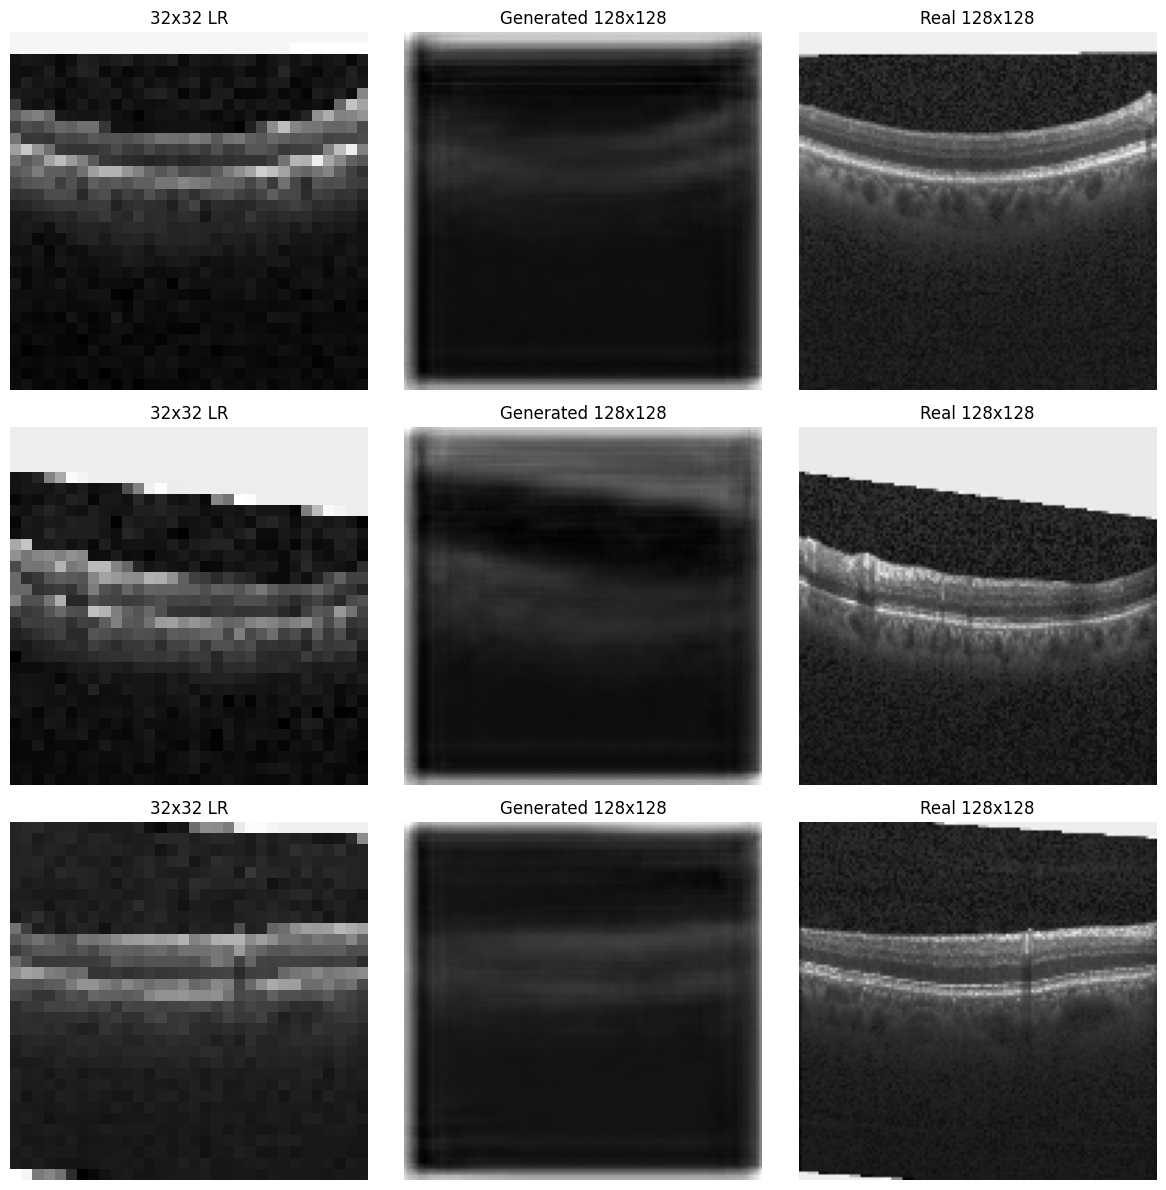

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_001.png

Epoch 2/10
  step 000 | gen_total=6.7159 | adv=1.1376 | pixel=0.0558 | disc=0.6064
  step 050 | gen_total=7.8085 | adv=1.5739 | pixel=0.0623 | disc=0.5452
  step 100 | gen_total=8.2949 | adv=1.5575 | pixel=0.0674 | disc=0.3594
Epoch 2 summary | gen_total=7.7811 | adv=1.8213 | pixel=0.0596 | disc=0.5589


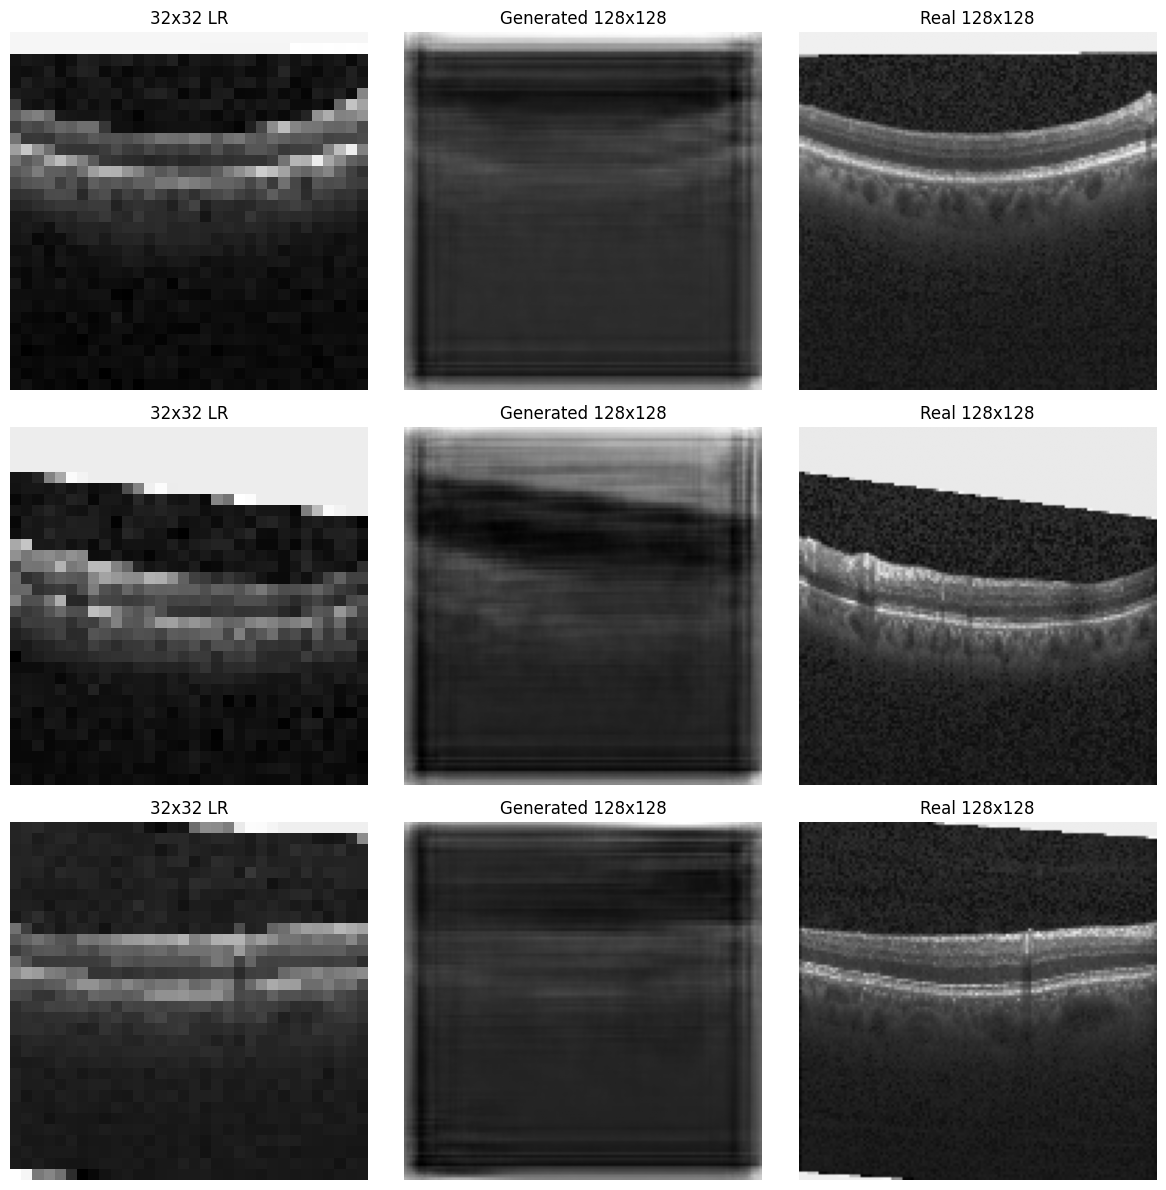

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_002.png

Epoch 3/10
  step 000 | gen_total=6.6683 | adv=0.9502 | pixel=0.0572 | disc=0.7030
  step 050 | gen_total=8.0505 | adv=2.9696 | pixel=0.0508 | disc=0.1811
  step 100 | gen_total=8.3935 | adv=2.3761 | pixel=0.0602 | disc=0.2153
Epoch 3 summary | gen_total=7.7098 | adv=1.9734 | pixel=0.0574 | disc=0.4561


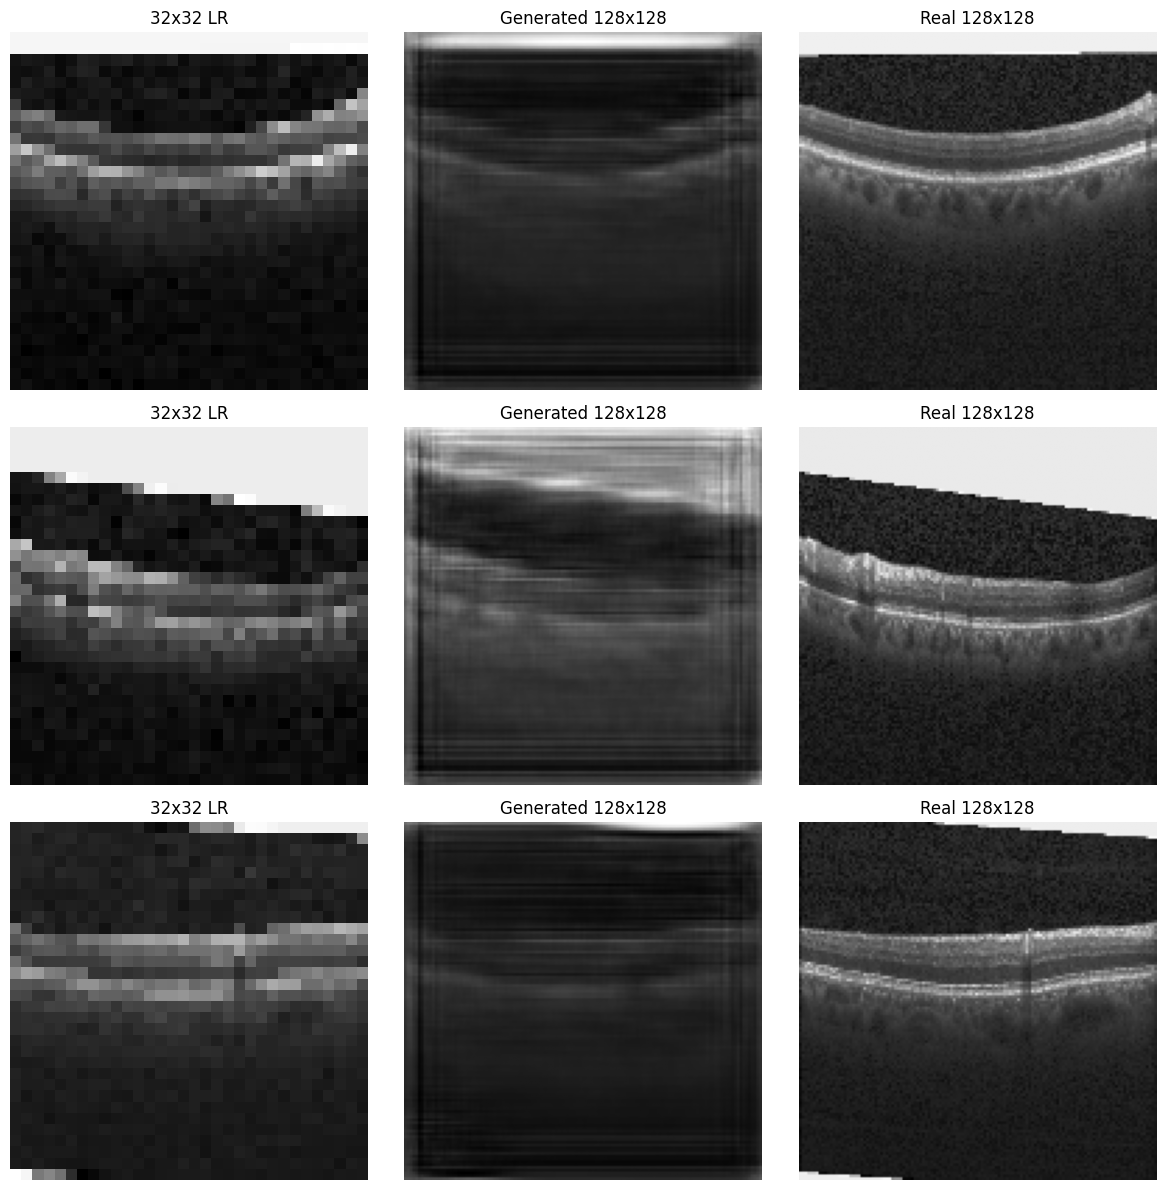

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_003.png

Epoch 4/10
  step 000 | gen_total=9.8765 | adv=3.3949 | pixel=0.0648 | disc=0.2207
  step 050 | gen_total=7.7948 | adv=1.5362 | pixel=0.0626 | disc=0.6928
  step 100 | gen_total=8.0925 | adv=1.5756 | pixel=0.0652 | disc=0.6506
Epoch 4 summary | gen_total=8.3115 | adv=2.3087 | pixel=0.0600 | disc=0.3589


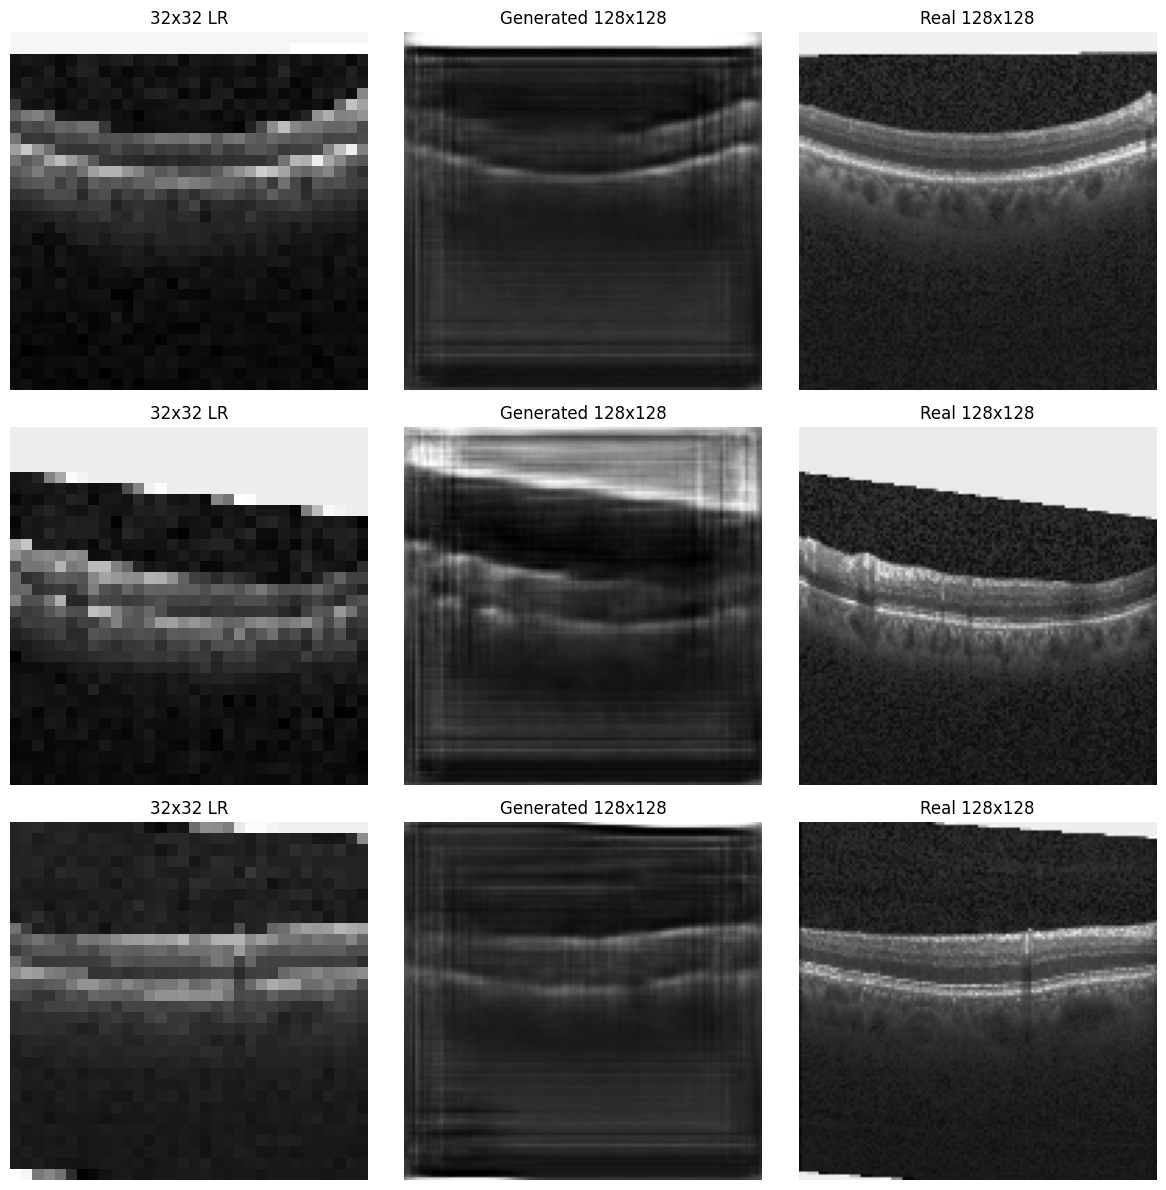

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_004.png

Epoch 5/10
  step 000 | gen_total=8.5672 | adv=2.2126 | pixel=0.0635 | disc=1.1671
  step 050 | gen_total=6.6941 | adv=0.9698 | pixel=0.0572 | disc=0.6576
  step 100 | gen_total=7.6923 | adv=1.8801 | pixel=0.0581 | disc=0.3269
Epoch 5 summary | gen_total=8.5791 | adv=2.7458 | pixel=0.0583 | disc=0.2619


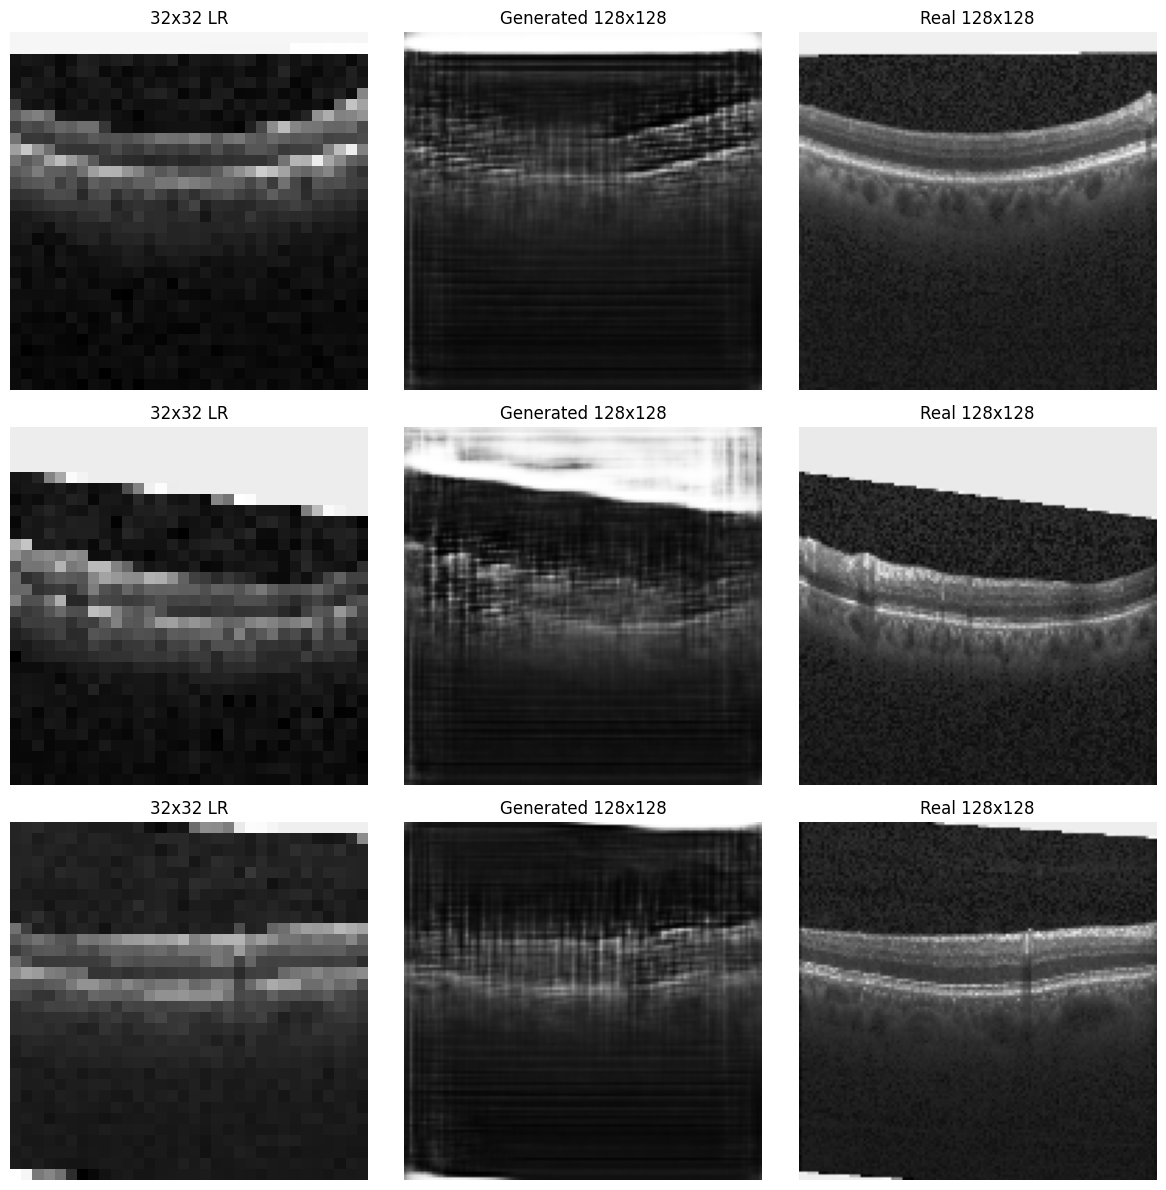

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_005.png

Epoch 6/10
  step 000 | gen_total=6.3469 | adv=0.6495 | pixel=0.0570 | disc=0.9395
  step 050 | gen_total=7.6723 | adv=1.6098 | pixel=0.0606 | disc=0.3571
  step 100 | gen_total=6.7568 | adv=1.5322 | pixel=0.0522 | disc=0.3306
Epoch 6 summary | gen_total=7.9722 | adv=2.0534 | pixel=0.0592 | disc=0.5700


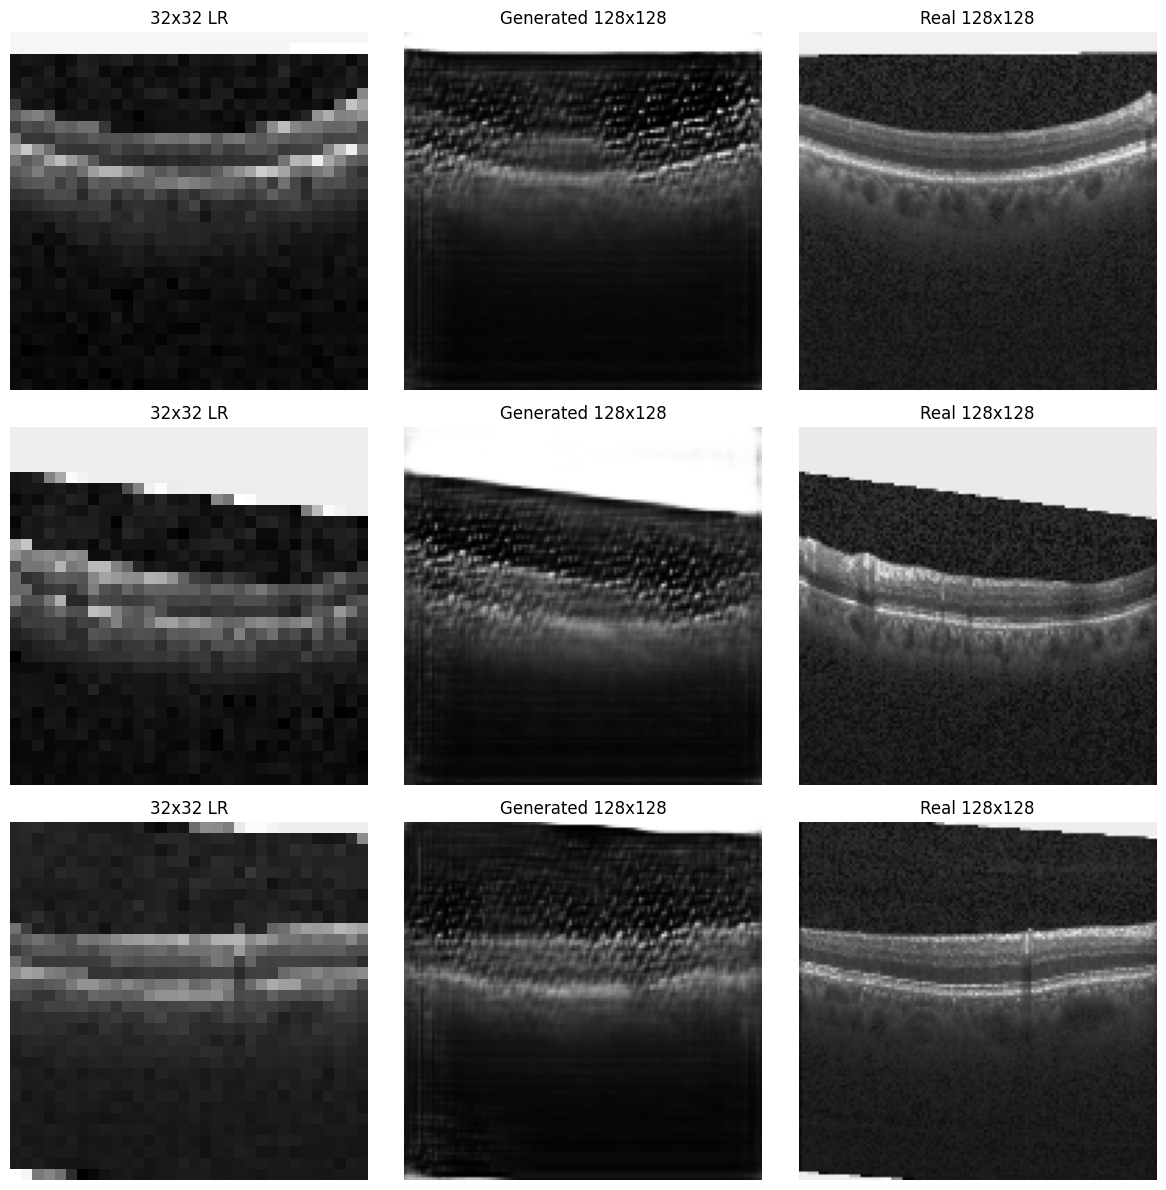

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_006.png

Epoch 7/10
  step 000 | gen_total=7.8615 | adv=1.8271 | pixel=0.0603 | disc=0.6165
  step 050 | gen_total=8.6640 | adv=2.4124 | pixel=0.0625 | disc=0.1965
  step 100 | gen_total=8.0994 | adv=1.5037 | pixel=0.0660 | disc=0.4910
Epoch 7 summary | gen_total=8.0461 | adv=2.0641 | pixel=0.0598 | disc=0.4920


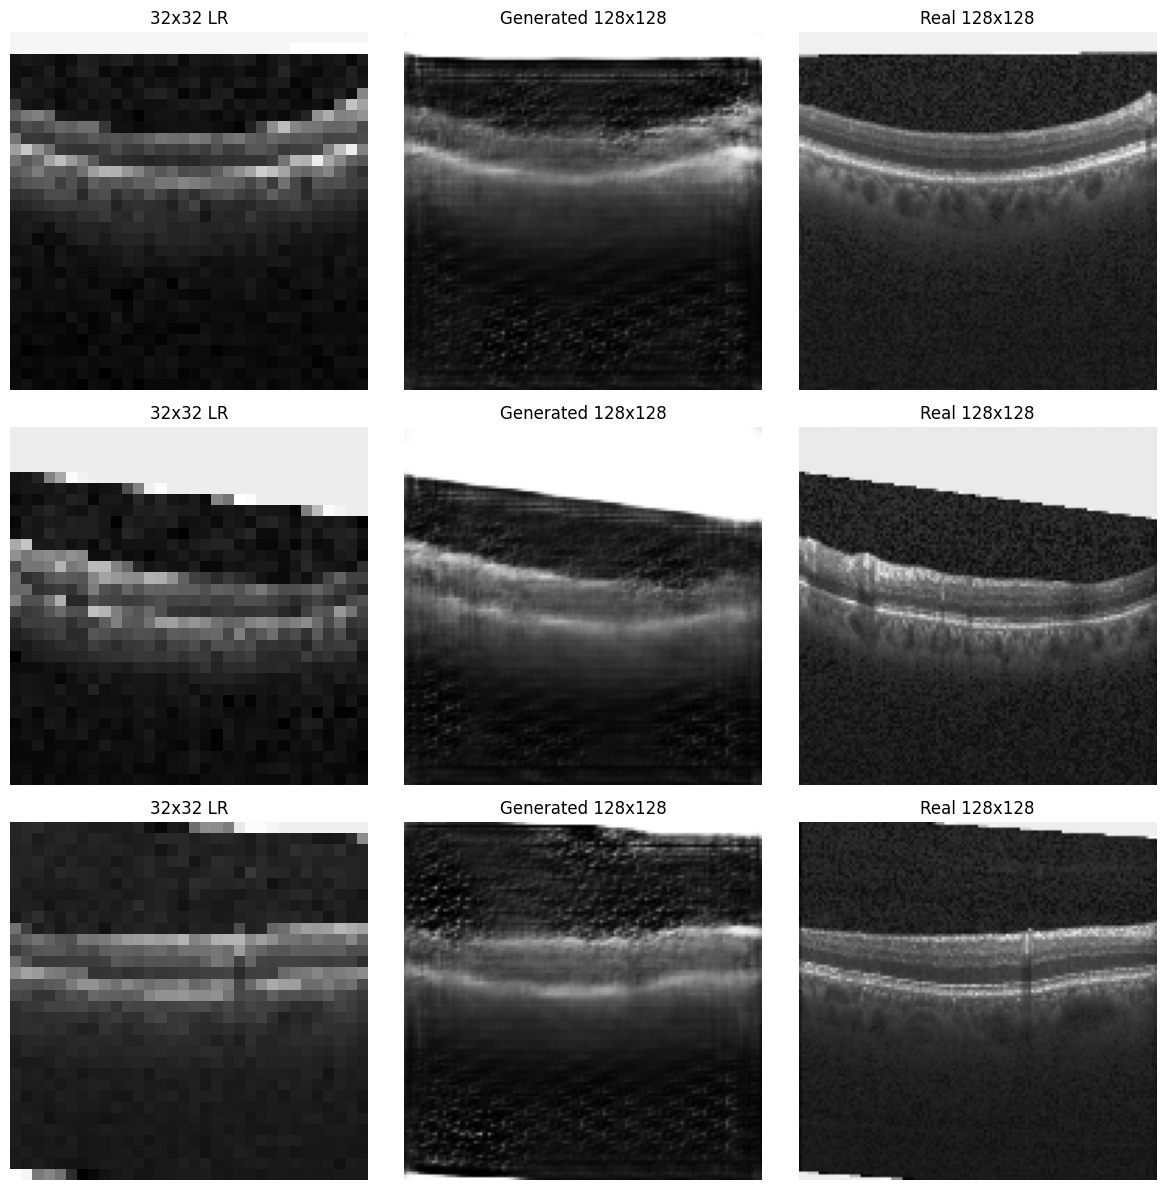

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_007.png

Epoch 8/10
  step 000 | gen_total=8.0921 | adv=1.5826 | pixel=0.0651 | disc=0.4809
  step 050 | gen_total=7.4126 | adv=0.9630 | pixel=0.0645 | disc=0.8796
  step 100 | gen_total=7.7873 | adv=2.4057 | pixel=0.0538 | disc=0.2460
Epoch 8 summary | gen_total=8.9815 | adv=2.6674 | pixel=0.0631 | disc=0.3597


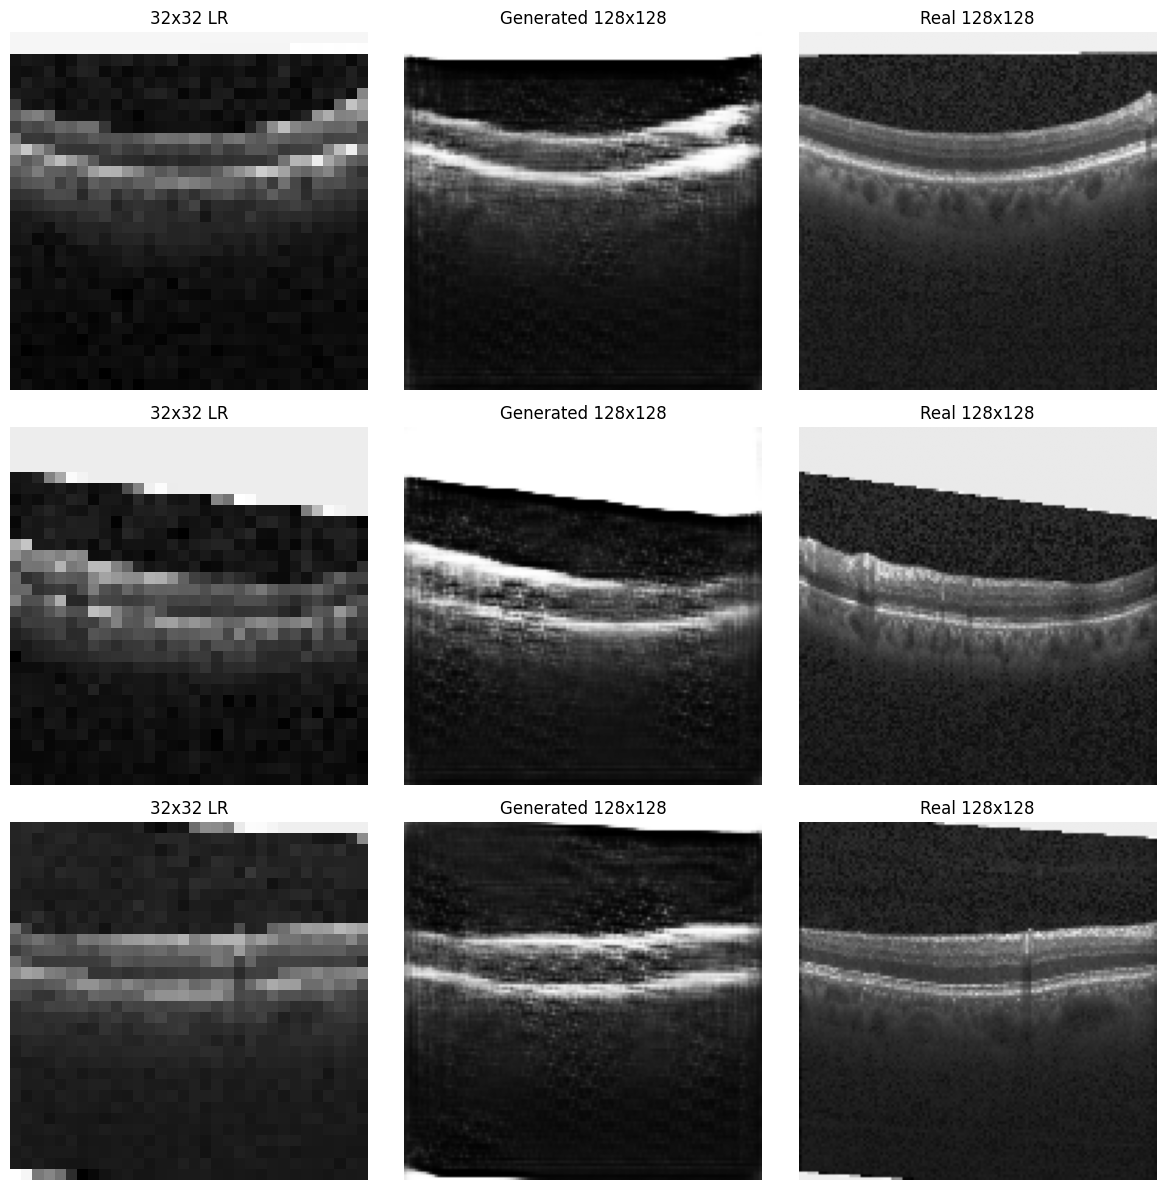

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_008.png

Epoch 9/10
  step 000 | gen_total=8.7975 | adv=2.4176 | pixel=0.0638 | disc=0.4794
  step 050 | gen_total=6.7334 | adv=1.0896 | pixel=0.0564 | disc=0.6595
  step 100 | gen_total=8.7377 | adv=3.2100 | pixel=0.0553 | disc=0.1125
Epoch 9 summary | gen_total=7.8544 | adv=2.1108 | pixel=0.0574 | disc=0.4945


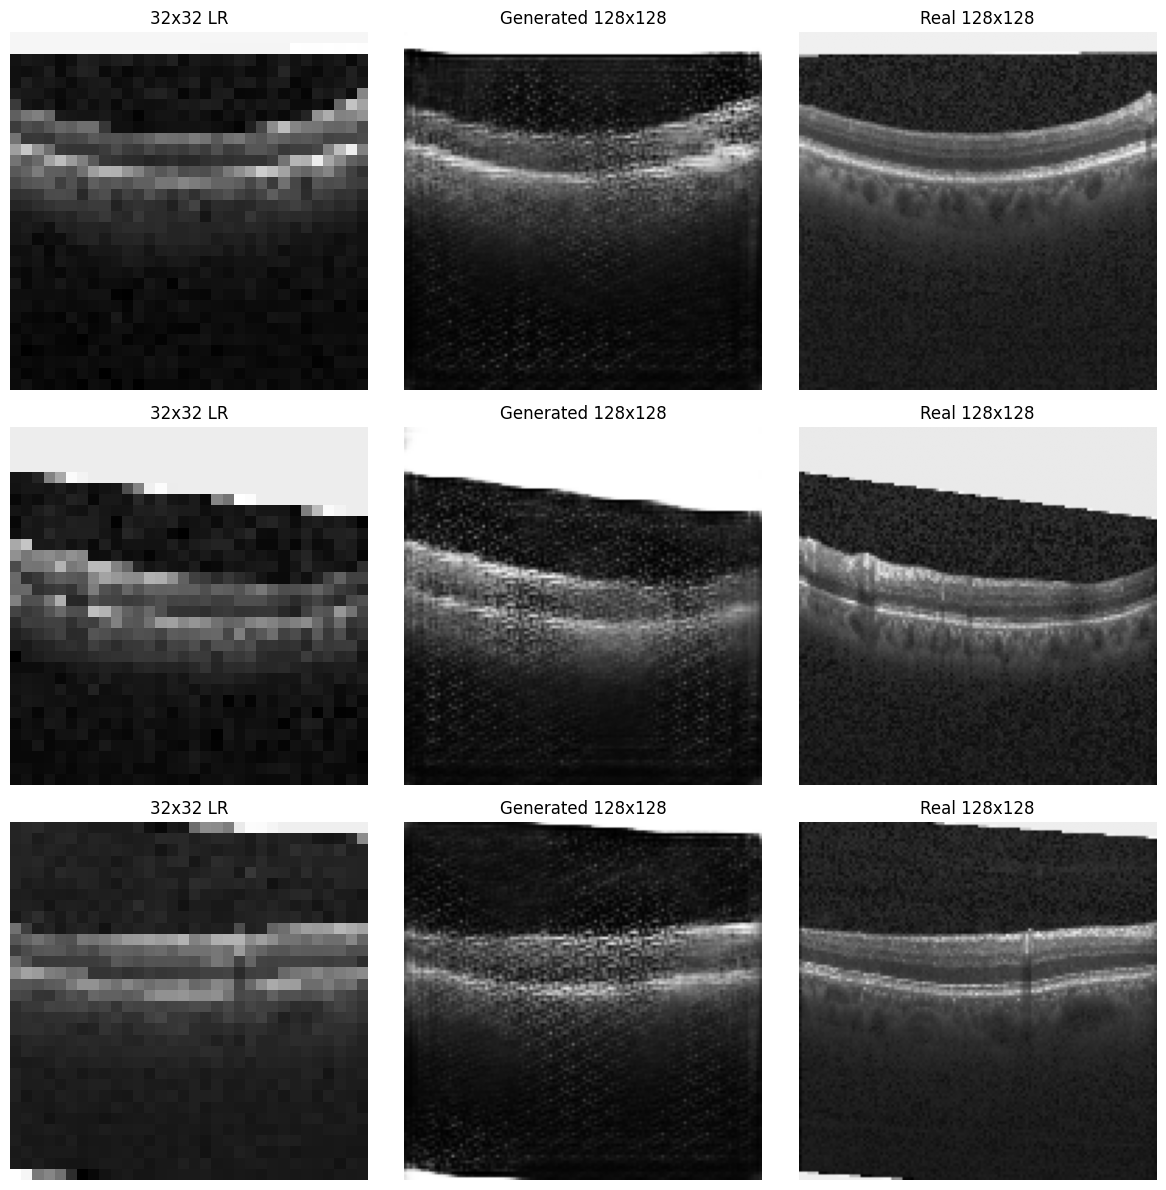

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_009.png

Epoch 10/10
  step 000 | gen_total=9.3554 | adv=3.3662 | pixel=0.0599 | disc=0.0607
  step 050 | gen_total=7.0124 | adv=1.4552 | pixel=0.0556 | disc=0.9375
  step 100 | gen_total=7.8844 | adv=2.5681 | pixel=0.0532 | disc=0.5874
Epoch 10 summary | gen_total=7.3123 | adv=1.7752 | pixel=0.0554 | disc=0.7130


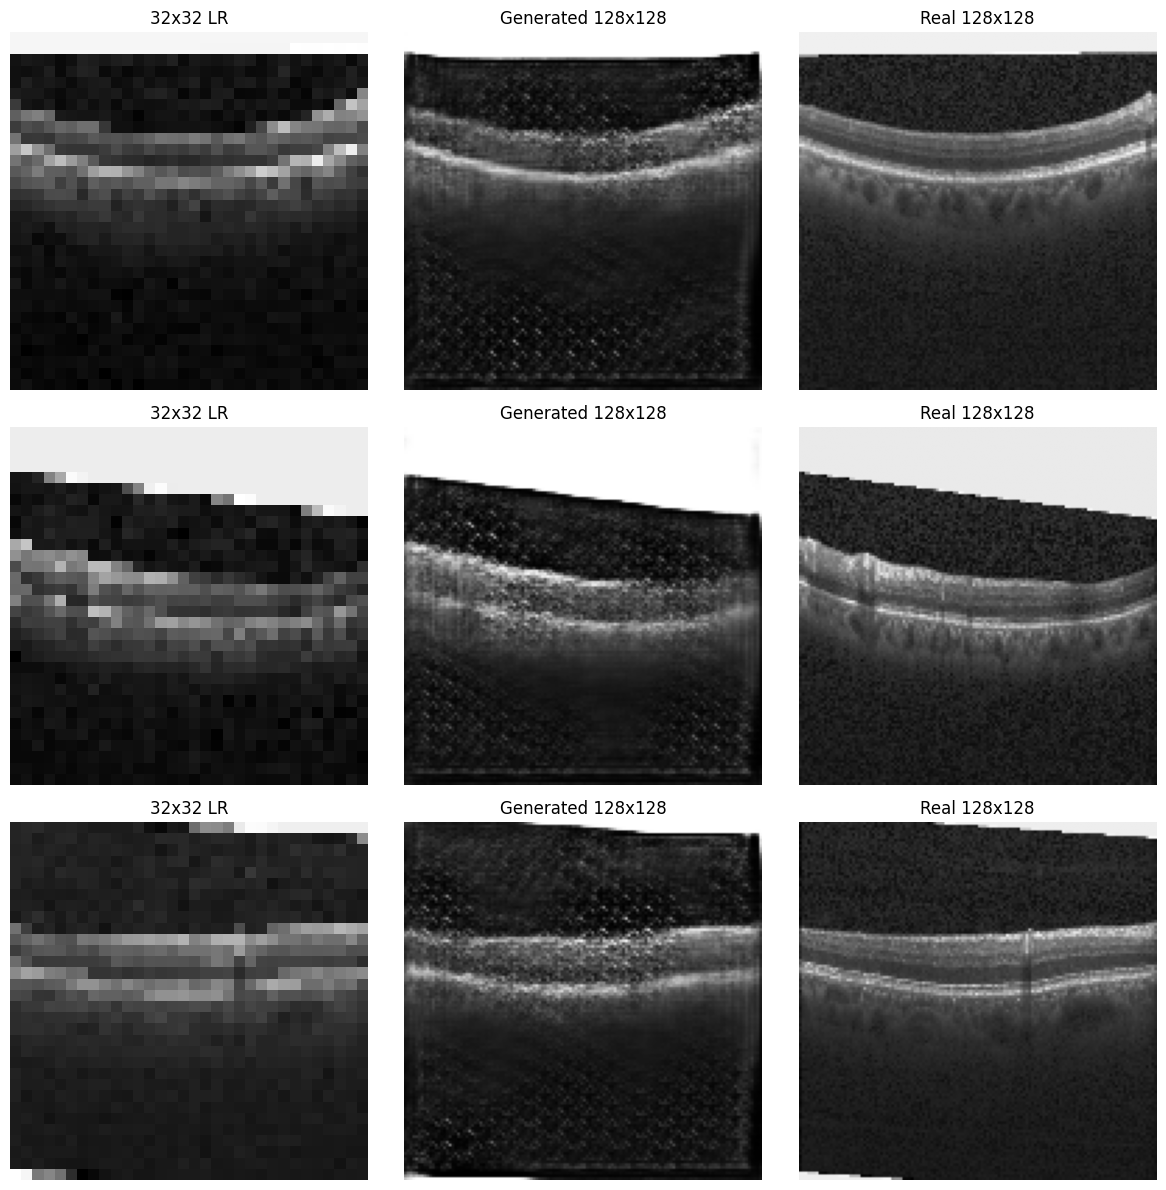

Saved sample image to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_samples/srgan_epoch_010.png


In [88]:
EPOCHS = 10

gen_loss_history = []
adv_loss_history = []
pixel_loss_history = []
disc_loss_history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    epoch_gen_loss = []
    epoch_adv_loss = []
    epoch_pixel_loss = []
    epoch_disc_loss = []

    for step, (lr_images, hr_images) in enumerate(srgan_train_ds):
        total_gen_loss, adv_loss, pixel_loss, disc_loss = train_step(lr_images, hr_images)

        epoch_gen_loss.append(total_gen_loss.numpy())
        epoch_adv_loss.append(adv_loss.numpy())
        epoch_pixel_loss.append(pixel_loss.numpy())
        epoch_disc_loss.append(disc_loss.numpy())

        if step % 50 == 0:
            print(
                f"  step {step:03d} | "
                f"gen_total={total_gen_loss.numpy():.4f} | "
                f"adv={adv_loss.numpy():.4f} | "
                f"pixel={pixel_loss.numpy():.4f} | "
                f"disc={disc_loss.numpy():.4f}"
            )

    mean_gen = np.mean(epoch_gen_loss)
    mean_adv = np.mean(epoch_adv_loss)
    mean_pixel = np.mean(epoch_pixel_loss)
    mean_disc = np.mean(epoch_disc_loss)

    gen_loss_history.append(mean_gen)
    adv_loss_history.append(mean_adv)
    pixel_loss_history.append(mean_pixel)
    disc_loss_history.append(mean_disc)

    print(
        f"Epoch {epoch} summary | "
        f"gen_total={mean_gen:.4f} | "
        f"adv={mean_adv:.4f} | "
        f"pixel={mean_pixel:.4f} | "
        f"disc={mean_disc:.4f}"
    )

    # save generator/discriminator checkpoints every epoch
    generator.save(os.path.join(SR_CHECKPOINT_DIR, f"generator_epoch_{epoch:03d}.keras"))
    discriminator.save(os.path.join(SR_CHECKPOINT_DIR, f"discriminator_epoch_{epoch:03d}.keras"))

    # save image samples every epoch
    save_sample_images(epoch, preview_lr, preview_hr, generator, SR_SAMPLE_DIR, num_examples=3)

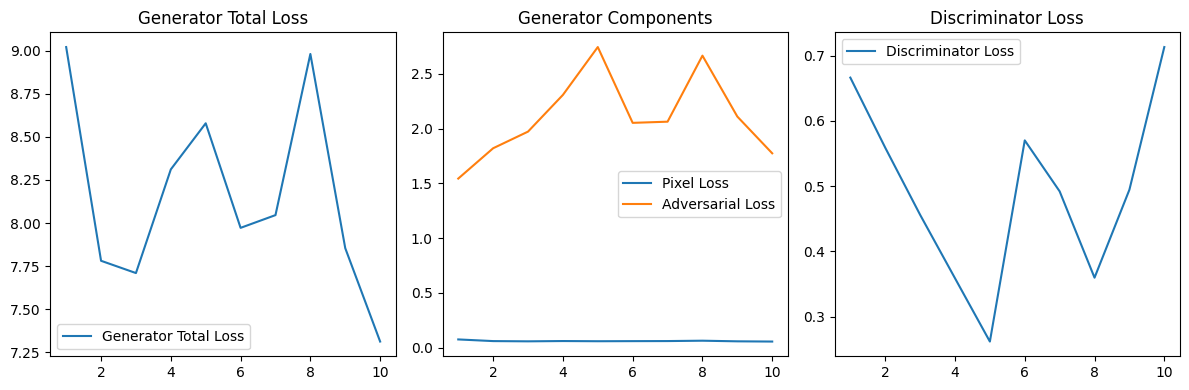

In [89]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, gen_loss_history, label="Generator Total Loss")
plt.title("Generator Total Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, pixel_loss_history, label="Pixel Loss")
plt.plot(epochs_range, adv_loss_history, label="Adversarial Loss")
plt.title("Generator Components")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_range, disc_loss_history, label="Discriminator Loss")
plt.title("Discriminator Loss")
plt.legend()

plt.tight_layout()
plt.show()

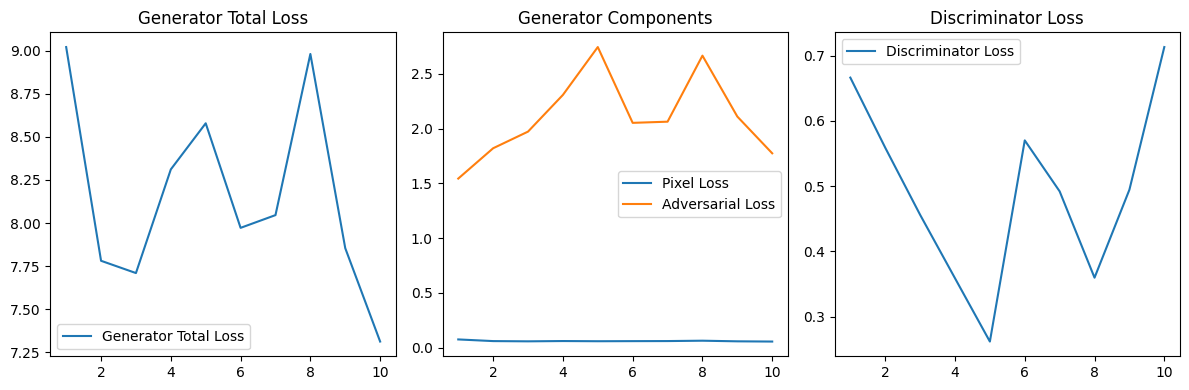

Saved SRGAN training curves to: /content/gdrive/MyDrive/Midterm_OCT_Project/srgan_outputs/srgan_training_curves.png


In [90]:
srgan_curve_path = os.path.join(SR_OUTPUT_ROOT, "srgan_training_curves.png")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, gen_loss_history, label="Generator Total Loss")
plt.title("Generator Total Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, pixel_loss_history, label="Pixel Loss")
plt.plot(epochs_range, adv_loss_history, label="Adversarial Loss")
plt.title("Generator Components")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_range, disc_loss_history, label="Discriminator Loss")
plt.title("Discriminator Loss")
plt.legend()

plt.tight_layout()
plt.savefig(srgan_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SRGAN training curves to:", srgan_curve_path)

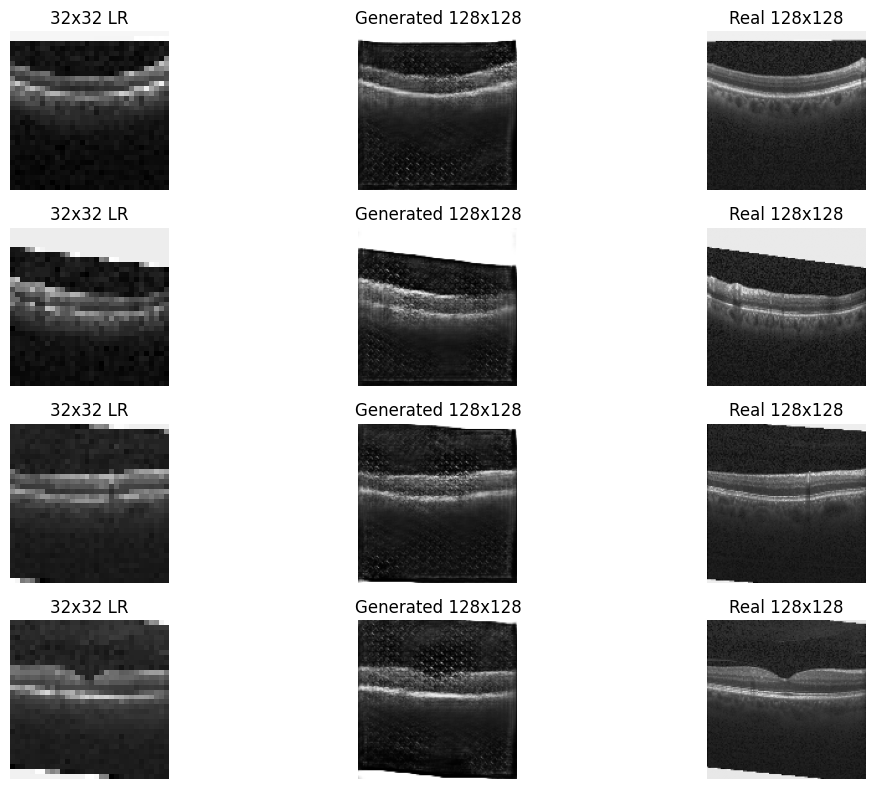

In [91]:
final_fake_hr = generator(preview_lr, training=False)

plt.figure(figsize=(12, 8))

for i in range(4):
    # LR input
    plt.subplot(4, 3, 3*i + 1)
    plt.imshow(tf.squeeze(preview_lr[i]), cmap="gray")
    plt.title("32x32 LR")
    plt.axis("off")

    # Generated SR
    plt.subplot(4, 3, 3*i + 2)
    plt.imshow(tf.squeeze(final_fake_hr[i]), cmap="gray")
    plt.title("Generated 128x128")
    plt.axis("off")

    # Real HR
    plt.subplot(4, 3, 3*i + 3)
    plt.imshow(tf.squeeze(preview_hr[i]), cmap="gray")
    plt.title("Real 128x128")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Day 4 — Train Model B Using SRGAN-Generated Images

## Main goal
Use the trained SRGAN generator to create 128×128 images from 32×32 inputs, then train a new classifier (Model B) on those generated images.

## Purpose
This stage tests whether super-resolved images help downstream binary classification compared with the Day 1 baseline model.


In [92]:
GENERATED_ROOT = os.path.join(PROJECT_ROOT, "generated_for_model_b")
ensure_dir(GENERATED_ROOT)

for cname in CLASS_NAMES:
    ensure_dir(os.path.join(GENERATED_ROOT, cname))

print("Generated image root:", GENERATED_ROOT)

Generated image root: /content/gdrive/MyDrive/Midterm_OCT_Project/generated_for_model_b


In [93]:
filepaths = []
labels = []

label_map = {"NORMAL": 0, "DME": 1}
reverse_label_map = {0: "NORMAL", 1: "DME"}

for cname in CLASS_NAMES:
    class_dir = os.path.join(PNG_ROOT, cname)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(".png"):
            filepaths.append(os.path.join(class_dir, fname))
            labels.append(label_map[cname])

filepaths = np.array(sorted(filepaths))
labels = np.array(labels)

print("Total images:", len(filepaths))
print("NORMAL count:", np.sum(labels == 0))
print("DME count:", np.sum(labels == 1))

Total images: 2508
NORMAL count: 1407
DME count: 1101


In [94]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    filepaths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_train_b,
    y_train_b,
    test_size=0.20,
    stratify=y_train_b,
    random_state=SEED
)

print("Model B train:", len(X_train_b))
print("Model B val:", len(X_val_b))
print("Model B test:", len(X_test_b))

Model B train: 1404
Model B val: 351
Model B test: 753


In [95]:
def generate_and_save_image(src_path, label, generator, save_root):
    # read original grayscale PNG
    image = tf.io.read_file(src_path)
    image = tf.image.decode_png(image, channels=1)

    # make HR base and LR input
    hr = tf.image.resize(image, SR_IMG_SIZE, method="bicubic")
    hr = tf.cast(hr, tf.float32) / 255.0

    lr = tf.image.resize(hr, LR_IMG_SIZE, method="bicubic")
    lr = tf.expand_dims(lr, axis=0)  # add batch dimension

    # generate SR image
    fake_hr = generator(lr, training=False)[0]  # remove batch dimension

    # convert to uint8 and save
    fake_hr_uint8 = tf.clip_by_value(fake_hr * 255.0, 0, 255)
    fake_hr_uint8 = tf.cast(fake_hr_uint8, tf.uint8).numpy().squeeze()

    class_name = reverse_label_map[label]
    base_name = os.path.basename(src_path)
    save_path = os.path.join(save_root, class_name, base_name)

    Image.fromarray(fake_hr_uint8).save(save_path)

    return save_path

In [96]:
generated_train_paths = []
generated_val_paths = []
generated_test_paths = []

print("Generating Model B training images...")
for path, label in zip(X_train_b, y_train_b):
    save_path = generate_and_save_image(path, label, generator, GENERATED_ROOT)
    generated_train_paths.append(save_path)

print("Generating Model B validation images...")
for path, label in zip(X_val_b, y_val_b):
    save_path = generate_and_save_image(path, label, generator, GENERATED_ROOT)
    generated_val_paths.append(save_path)

print("Generating Model B test images...")
for path, label in zip(X_test_b, y_test_b):
    save_path = generate_and_save_image(path, label, generator, GENERATED_ROOT)
    generated_test_paths.append(save_path)

generated_train_paths = np.array(generated_train_paths)
generated_val_paths = np.array(generated_val_paths)
generated_test_paths = np.array(generated_test_paths)

print("Done generating Model B dataset.")
print("Generated train:", len(generated_train_paths))
print("Generated val:", len(generated_val_paths))
print("Generated test:", len(generated_test_paths))

Generating Model B training images...
Generating Model B validation images...
Generating Model B test images...
Done generating Model B dataset.
Generated train: 1404
Generated val: 351
Generated test: 753


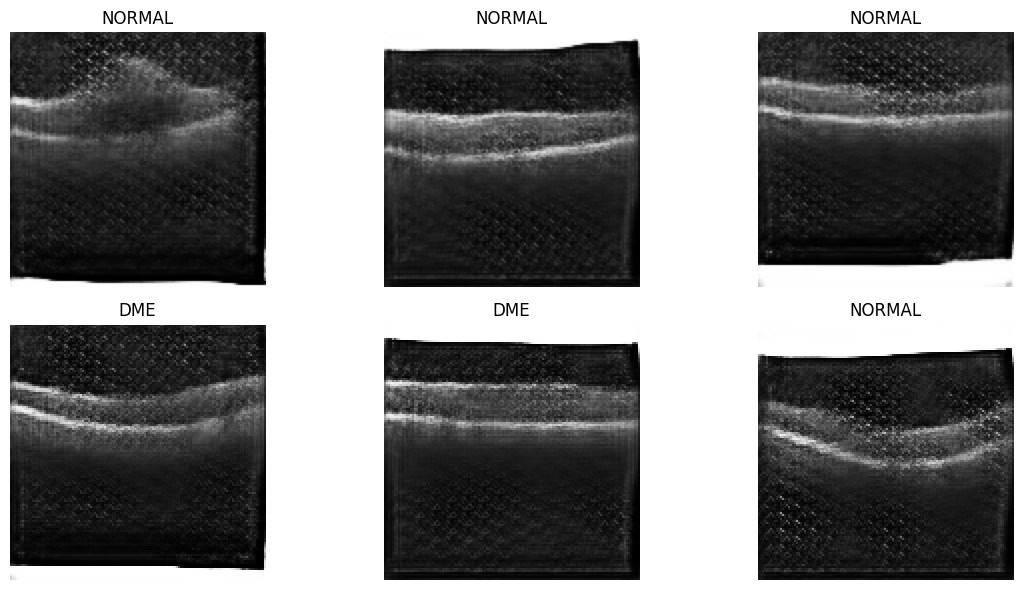

In [97]:
plt.figure(figsize=(12, 6))

for i in range(6):
    img = Image.open(generated_train_paths[i]).convert("L")
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(reverse_label_map[y_train_b[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [98]:
def load_generated_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.grayscale_to_rgb(image)
    return image, label

def make_model_b_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_generated_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_b_ds = make_model_b_dataset(generated_train_paths, y_train_b, training=True)
val_b_ds = make_model_b_dataset(generated_val_paths, y_val_b, training=False)
test_b_ds = make_model_b_dataset(generated_test_paths, y_test_b, training=False)

print("Model B datasets ready.")

Model B datasets ready.


In [99]:
base_model_b = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model_b.trainable = False

inputs = keras.Input(shape=(128, 128, 3))
x = base_model_b(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_b = keras.Model(inputs, outputs, name="Model_B_ResNet50")

model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc")
    ]
)

model_b.summary()

Model: "Model_B_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [101]:
model_b_epoch_dir = os.path.join(MODEL_ROOT, "model_b_epoch_checkpoints")
ensure_dir(model_b_epoch_dir)

checkpoint_every_epoch_b = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(model_b_epoch_dir, "model_b_epoch_{epoch:03d}.keras"),
    save_freq="epoch",
    save_weights_only=False,
    verbose=1
)

In [102]:
model_b_path = os.path.join(MODEL_ROOT, "model_b_best.keras")

callbacks_b = [
    checkpoint_every_epoch_b,
    keras.callbacks.ModelCheckpoint(
        filepath=model_b_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

history_b = model_b.fit(
    train_b_ds,
    validation_data=val_b_ds,
    epochs=100,
    callbacks=callbacks_b
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.4699 - auc: 0.4818 - loss: 0.7848
Epoch 1: saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_epoch_checkpoints/model_b_epoch_001.keras

Epoch 1: finished saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_epoch_checkpoints/model_b_epoch_001.keras

Epoch 1: val_auc improved from None to 0.57285, saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_best.keras

Epoch 1: finished saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 671ms/step - accuracy: 0.4736 - auc: 0.4999 - loss: 0.7699 - val_accuracy: 0.4387 - val_auc: 0.5728 - val_loss: 0.7193
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.4551 - auc: 0.4739 - loss: 0.7586
Epoch 2: saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_epoch_checkpoints/model_b_epoch_002.keras

Epoch 2: finished s

In [103]:
base_model_b.trainable = True

fine_tune_at_b = len(base_model_b.layers) - 40

for layer in base_model_b.layers[:fine_tune_at_b]:
    layer.trainable = False

model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc")
    ]
)

model_b_finetuned_path = os.path.join(MODEL_ROOT, "model_b_finetuned_best.keras")

callbacks_b_ft = [
    keras.callbacks.ModelCheckpoint(
        filepath=model_b_finetuned_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history_b_ft = model_b.fit(
    train_b_ds,
    validation_data=val_b_ds,
    epochs=50,
    callbacks=callbacks_b_ft
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.6288 - auc: 0.6628 - loss: 0.7536
Epoch 1: val_auc improved from None to 0.65225, saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_finetuned_best.keras

Epoch 1: finished saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_finetuned_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 64s 996ms/step - accuracy: 0.6774 - auc: 0.7313 - loss: 0.6192 - val_accuracy: 0.5613 - val_auc: 0.6523 - val_loss: 0.6846
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.7439 - auc: 0.8349 - loss: 0.4878
Epoch 2: val_auc improved from 0.65225 to 0.65725, saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_finetuned_best.keras

Epoch 2: finished saving model to /content/gdrive/MyDrive/Midterm_OCT_Project/models/model_b_finetuned_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 458ms/step - accuracy: 0.7450 - auc: 0.8359 - loss: 0.4851 - val_accuracy: 0.5613 - val_auc: 0.657

In [104]:
y_prob_b = model_b.predict(test_b_ds).ravel()
y_pred_b = (y_prob_b >= 0.5).astype(int)
y_true_b = np.concatenate([y.numpy() for _, y in test_b_ds], axis=0)

acc_b = accuracy_score(y_true_b, y_pred_b)
f1_b = f1_score(y_true_b, y_pred_b)
auc_b = roc_auc_score(y_true_b, y_prob_b)

print(f"Model B Test Accuracy: {acc_b:.4f}")
print(f"Model B Test F1 Score: {f1_b:.4f}")
print(f"Model B Test AUC:      {auc_b:.4f}")
print("Predicted class counts:", np.bincount(y_pred_b))
print("True class counts:", np.bincount(y_true_b))

24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step
Model B Test Accuracy: 0.8459
Model B Test F1 Score: 0.8449
Model B Test AUC:      0.9523
Predicted class counts: [336 417]
True class counts: [422 331]


              precision    recall  f1-score   support

      NORMAL       0.96      0.76      0.85       422
         DME       0.76      0.95      0.84       331

    accuracy                           0.85       753
   macro avg       0.86      0.86      0.85       753
weighted avg       0.87      0.85      0.85       753



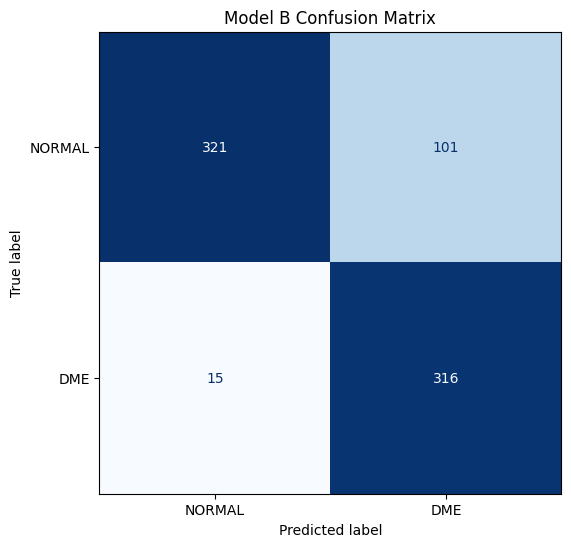

In [105]:
print(classification_report(
    y_true_b,
    y_pred_b,
    target_names=["NORMAL", "DME"]
))

cm_b = confusion_matrix(y_true_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=["NORMAL", "DME"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Model B Confusion Matrix")
plt.show()

In [106]:
model_a_results = {
    "Accuracy": 0.5750,
    "F1": 0.0698,
    "AUC": 0.6873
}

model_b_results = {
    "Accuracy": acc_b,
    "F1": f1_b,
    "AUC": auc_b
}

print("Model comparison:")
for metric in ["Accuracy", "F1", "AUC"]:
    print(f"{metric}: Model A = {model_a_results[metric]:.4f}, Model B = {model_b_results[metric]:.4f}")

Model comparison:
Accuracy: Model A = 0.5750, Model B = 0.8459
F1: Model A = 0.0698, Model B = 0.8449
AUC: Model A = 0.6873, Model B = 0.9523


In [107]:
comparison_metrics_path = os.path.join(OUTPUT_ROOT, "final_model_comparison.txt")

with open(comparison_metrics_path, "w") as f:
    f.write("Final Model Comparison\n")
    f.write("======================\n\n")
    f.write(f"Model A Accuracy: {model_a_results['Accuracy']:.4f}\n")
    f.write(f"Model A F1:       {model_a_results['F1']:.4f}\n")
    f.write(f"Model A AUC:      {model_a_results['AUC']:.4f}\n\n")

    f.write(f"Model B Accuracy: {model_b_results['Accuracy']:.4f}\n")
    f.write(f"Model B F1:       {model_b_results['F1']:.4f}\n")
    f.write(f"Model B AUC:      {model_b_results['AUC']:.4f}\n\n")

    f.write("Improvement (Model B - Model A)\n")
    f.write("===============================\n")
    f.write(f"Accuracy gain: {model_b_results['Accuracy'] - model_a_results['Accuracy']:.4f}\n")
    f.write(f"F1 gain:       {model_b_results['F1'] - model_a_results['F1']:.4f}\n")
    f.write(f"AUC gain:      {model_b_results['AUC'] - model_a_results['AUC']:.4f}\n")

print("Saved final comparison metrics to:", comparison_metrics_path)

Saved final comparison metrics to: /content/gdrive/MyDrive/Midterm_OCT_Project/outputs/final_model_comparison.txt


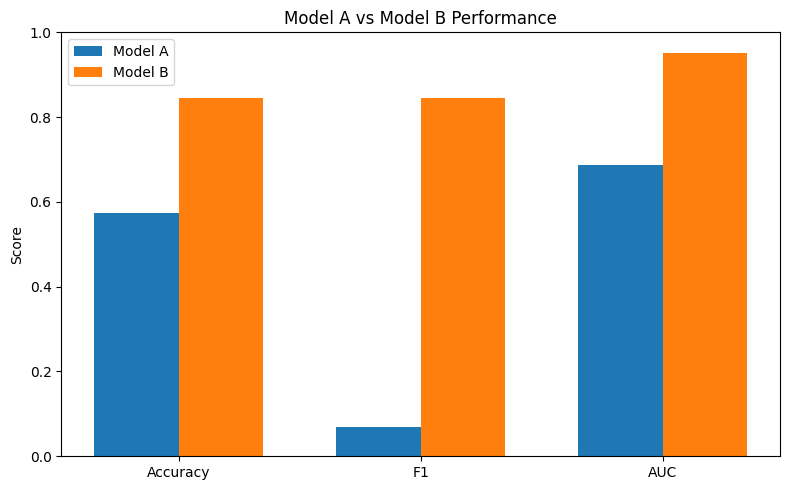

In [108]:
metrics = ["Accuracy", "F1", "AUC"]
model_a_vals = [model_a_results[m] for m in metrics]
model_b_vals = [model_b_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, model_a_vals, width, label="Model A")
plt.bar(x + width/2, model_b_vals, width, label="Model B")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Model A vs Model B Performance")
plt.legend()
plt.tight_layout()
plt.show()

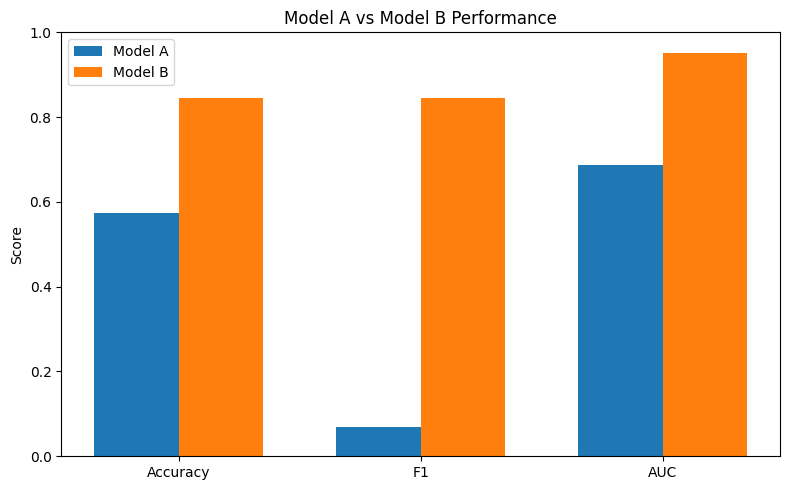

Saved comparison plot to: /content/gdrive/MyDrive/Midterm_OCT_Project/outputs/model_a_vs_model_b_barplot.png


In [109]:
comparison_plot_path = os.path.join(OUTPUT_ROOT, "model_a_vs_model_b_barplot.png")

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, model_a_vals, width, label="Model A")
plt.bar(x + width/2, model_b_vals, width, label="Model B")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Model A vs Model B Performance")
plt.legend()
plt.tight_layout()
plt.savefig(comparison_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved comparison plot to:", comparison_plot_path)

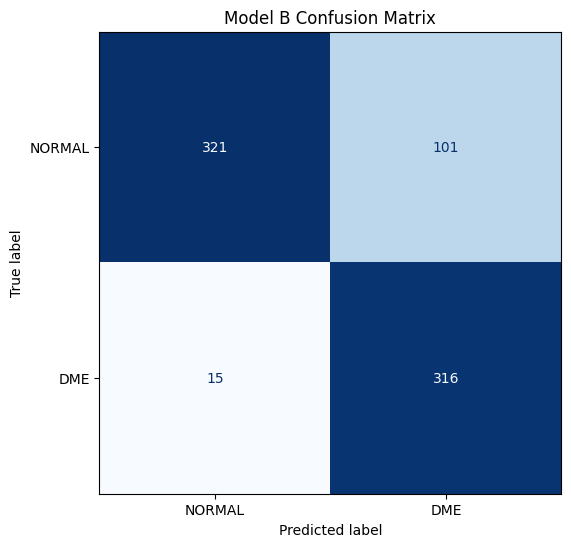

Saved Model B confusion matrix to: /content/gdrive/MyDrive/Midterm_OCT_Project/outputs/model_b_confusion_matrix.png


In [110]:
model_b_cm_path = os.path.join(OUTPUT_ROOT, "model_b_confusion_matrix.png")

cm_b = confusion_matrix(y_true_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=["NORMAL", "DME"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Model B Confusion Matrix")
plt.savefig(model_b_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Model B confusion matrix to:", model_b_cm_path)

In [111]:
model_b_metrics_path = os.path.join(OUTPUT_ROOT, "model_b_metrics.txt")

with open(model_b_metrics_path, "w") as f:
    f.write("Model B Results\n")
    f.write("===============\n")
    f.write(f"Test Accuracy: {acc_b:.4f}\n")
    f.write(f"Test F1 Score: {f1_b:.4f}\n")
    f.write(f"Test AUC: {auc_b:.4f}\n\n")
    f.write("Predicted class counts:\n")
    f.write(str(np.bincount(y_pred_b)) + "\n\n")
    f.write("True class counts:\n")
    f.write(str(np.bincount(y_true_b)) + "\n\n")
    f.write("Classification Report\n")
    f.write("=====================\n")
    f.write(classification_report(
        y_true_b,
        y_pred_b,
        target_names=["NORMAL", "DME"]
    ))

print("Saved Model B metrics to:", model_b_metrics_path)

Saved Model B metrics to: /content/gdrive/MyDrive/Midterm_OCT_Project/outputs/model_b_metrics.txt
